In [1]:
#Lab 4: Regression Analysis with Regularization Techniques
#Abhishek Pandey
#Advanced Big Data and Data Mining (MSCS-634-M20)
#Diabetes Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
df.shape
df.describe()
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [4]:
X_simple = df[['bmi']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

In [5]:
mae = mean_absolute_error(y_test, y_pred_simple)
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression Results:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Simple Linear Regression Results:
MAE: 52.259976445345536
MSE: 4061.8259284949268
RMSE: 63.73245584860925
R²: 0.23335039815872138


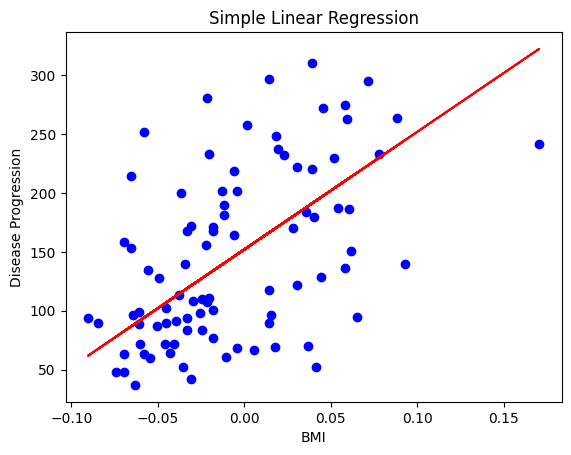

In [6]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred_simple, color='red')
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression")
plt.show()

In [7]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

y_pred_multiple = model_multiple.predict(X_test)

In [8]:
mae = mean_absolute_error(y_test, y_pred_multiple)
mse = mean_squared_error(y_test, y_pred_multiple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_multiple)

print("Multiple Regression Results:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Multiple Regression Results:
MAE: 42.79409467959994
MSE: 2900.193628493482
RMSE: 53.85344583676593
R²: 0.4526027629719195


In [9]:
mae = mean_absolute_error(y_test, y_pred_multiple)
mse = mean_squared_error(y_test, y_pred_multiple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_multiple)

print("Multiple Regression Results:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Multiple Regression Results:
MAE: 42.79409467959994
MSE: 2900.193628493482
RMSE: 53.85344583676593
R²: 0.4526027629719195


In [10]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

y_pred_poly = model_poly.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Results:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Polynomial Regression Results:
MAE: 43.58169325465221
MSE: 3096.0283073442656
RMSE: 55.6419653440123
R²: 0.4156399336408013


In [12]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge R²:", r2_score(y_test, y_pred_ridge))

Ridge R²: 0.41958396582030866


In [13]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso R²:", r2_score(y_test, y_pred_lasso))

Lasso R²: 0.4718547867276227


In [14]:
results = pd.DataFrame({
    "Model": ["Simple", "Multiple", "Polynomial", "Ridge", "Lasso"],
    "R2 Score": [
        r2_score(y_test, y_pred_simple),
        r2_score(y_test, y_pred_multiple),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

results

,Model,R2 Score
0,Simple,0.233350
1,Multiple,0.452603
2,Polynomial,0.415640
3,Ridge,0.419584
4,Lasso,0.471855
